Importações de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import io

In [37]:
dados = pd.read_csv('Prata.csv', sep = ';', encoding = 'utf-8', decimal = ',')
dados.head()




,data_Lançamento,1. Pessoal Ativo,2. Pessoal Inativo e Pensionistas,4. Indenizações por Demissão e Incentivo à Demissão,5. Decorrentes de Decisão Judicial,6. Despesas de Exercicios Anteriores,7. Inativos e Pensionistas com Recursos Vinculados,9. Receita Corrente,10. Deduções
0,01-2014,546275104.8,237679792.2,95078.1,39518804.8,6875489.3,242785069.3,NaN,NaN
1,02-2014,507208402.1,239350976.8,820596.7,500984.2,10219039.0,275530266.8,NaN,NaN
2,03-2014,538507826.7,256959731.4,4039555.7,374553.7,4103068.5,271377435.4,NaN,NaN
3,04-2014,396504353.4,249888179.7,1429427.1,200311.1,1401537.3,224522910.7,NaN,NaN
4,05-2014,647862745.1,260413679.0,2623260.2,1507337.4,10771273.4,298774669.7,NaN,NaN


In [38]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 9 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   data_Lançamento                                      147 non-null    object 
 1   1. Pessoal Ativo                                     146 non-null    float64
 2   2. Pessoal Inativo e Pensionistas                    146 non-null    float64
 3   4. Indenizações por Demissão e Incentivo à Demissão  132 non-null    float64
 4   5. Decorrentes de Decisão Judicial                   132 non-null    float64
 5   6. Despesas de Exercicios Anteriores                 132 non-null    float64
 6   7. Inativos e Pensionistas com Recursos Vinculados   146 non-null    float64
 7   9. Receita Corrente                                  135 non-null    float64
 8   10. Deduções                                         135 non-null    fl

In [39]:
dados['Data'] = pd.to_datetime(dados['data_Lançamento'], format='%m-%Y')

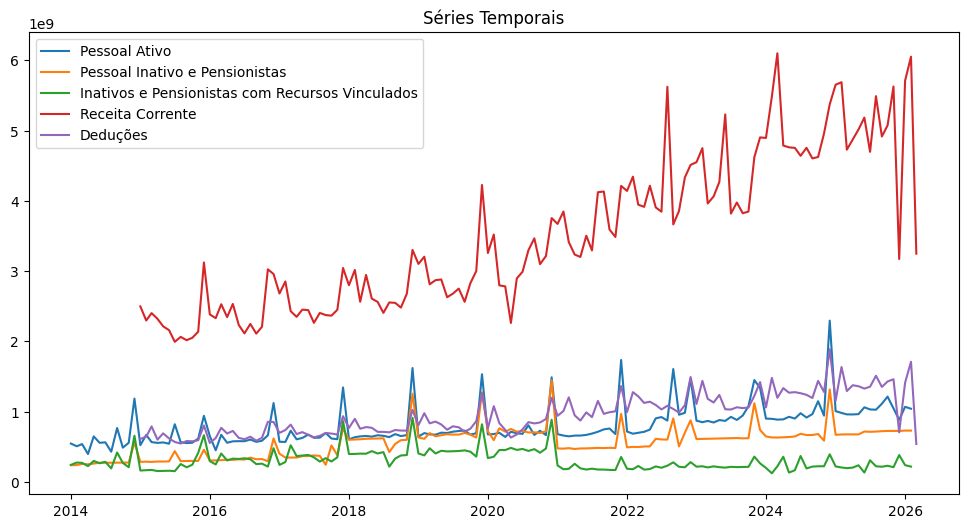

In [40]:
plt.figure(figsize=(12, 6))

plt.plot('Data', '1. Pessoal Ativo', data=dados, label='Pessoal Ativo')
plt.plot('Data', '2. Pessoal Inativo e Pensionistas', data=dados, label='Pessoal Inativo e Pensionistas')
plt.plot('Data', '7. Inativos e Pensionistas com Recursos Vinculados', data=dados, label='Inativos e Pensionistas com Recursos Vinculados')
plt.plot('Data', '9. Receita Corrente', data=dados, label='Receita Corrente')
plt.plot('Data', '10. Deduções', data=dados, label='Deduções')

plt.title('Séries Temporais')
plt.legend() # Importante para mostrar os labels
plt.show()

In [48]:
PA = pd.DataFrame(dados[['Data','1. Pessoal Ativo']]).dropna()
PI = pd.DataFrame(dados[['Data','2. Pessoal Inativo e Pensionistas']]).dropna()
IP = pd.DataFrame(dados[['Data','7. Inativos e Pensionistas com Recursos Vinculados']]).dropna()
RC = pd.DataFrame(dados[['Data','9. Receita Corrente']]).dropna()
DE = pd.DataFrame(dados[['Data','10. Deduções']]).dropna()

Gráficos ACF e PACF: Pessoal Ativo

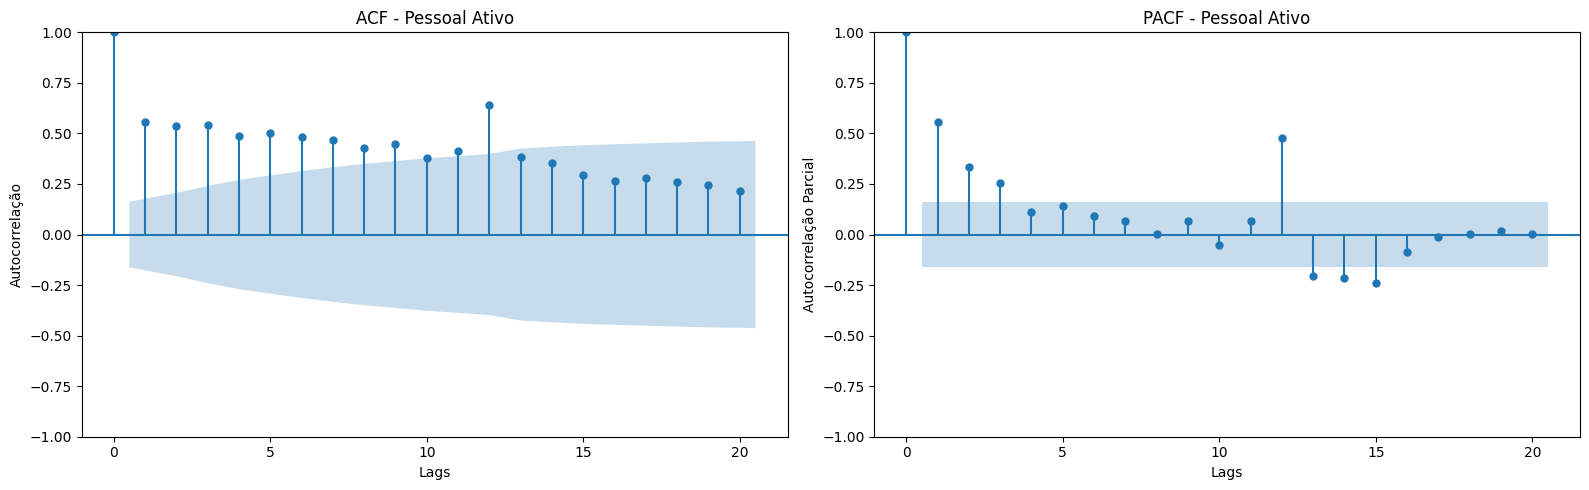

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(PI['2. Pessoal Inativo e Pensionistas'], ax=axes[0], lags=20)
axes[0].set_title('ACF - Pessoal Ativo')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelação')  
plot_pacf(PI['2. Pessoal Inativo e Pensionistas'], ax=axes[1], lags=20)
axes[1].set_title('PACF - Pessoal Ativo')   
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Autocorrelação Parcial')
plt.tight_layout()
plt.show()    


Gráficos ACF e PACF: Pessoal Inativo

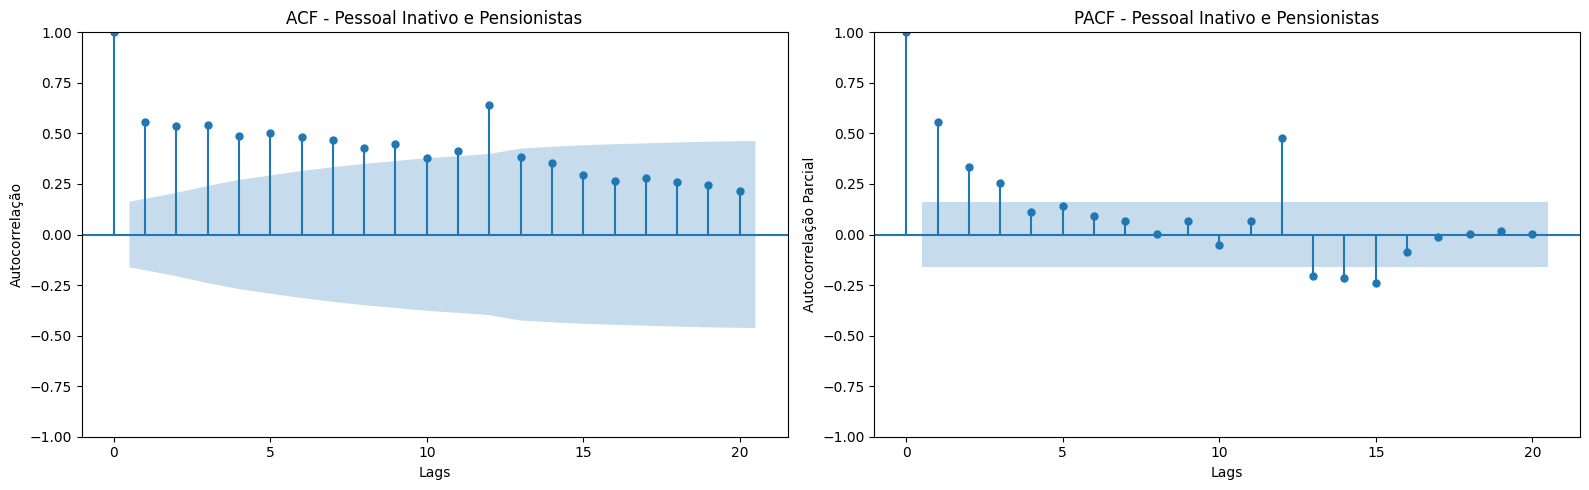

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(PI['2. Pessoal Inativo e Pensionistas'], ax=axes[0], lags=20)
axes[0].set_title('ACF - Pessoal Inativo e Pensionistas')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelação')  
plot_pacf(PI['2. Pessoal Inativo e Pensionistas'], ax=axes[1], lags=20)
axes[1].set_title('PACF - Pessoal Inativo e Pensionistas')   
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Autocorrelação Parcial')
plt.tight_layout()
plt.show()    


Gráficos ACF e PACF: Recurso Vinculado

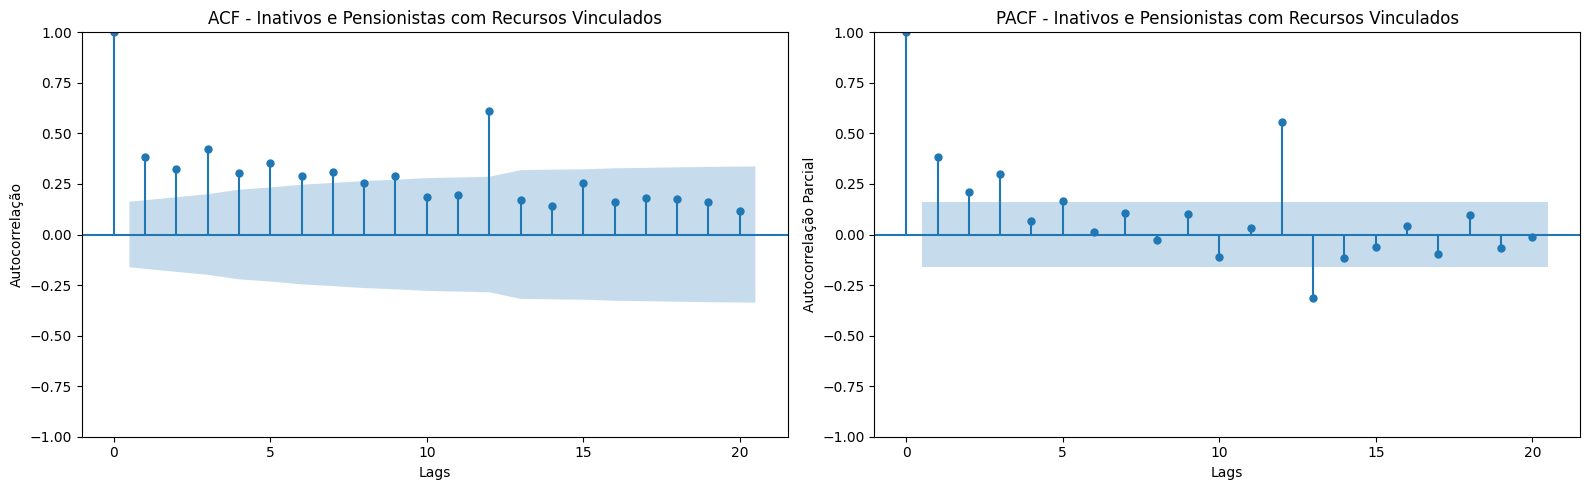

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(IP['7. Inativos e Pensionistas com Recursos Vinculados'], ax=axes[0], lags=20)
axes[0].set_title('ACF - Inativos e Pensionistas com Recursos Vinculados')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelação')  
plot_pacf(IP['7. Inativos e Pensionistas com Recursos Vinculados'], ax=axes[1], lags=20)
axes[1].set_title('PACF - Inativos e Pensionistas com Recursos Vinculados')   
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Autocorrelação Parcial')
plt.tight_layout()
plt.show()    


Gráficos ACF e PACF: Receita Corrente

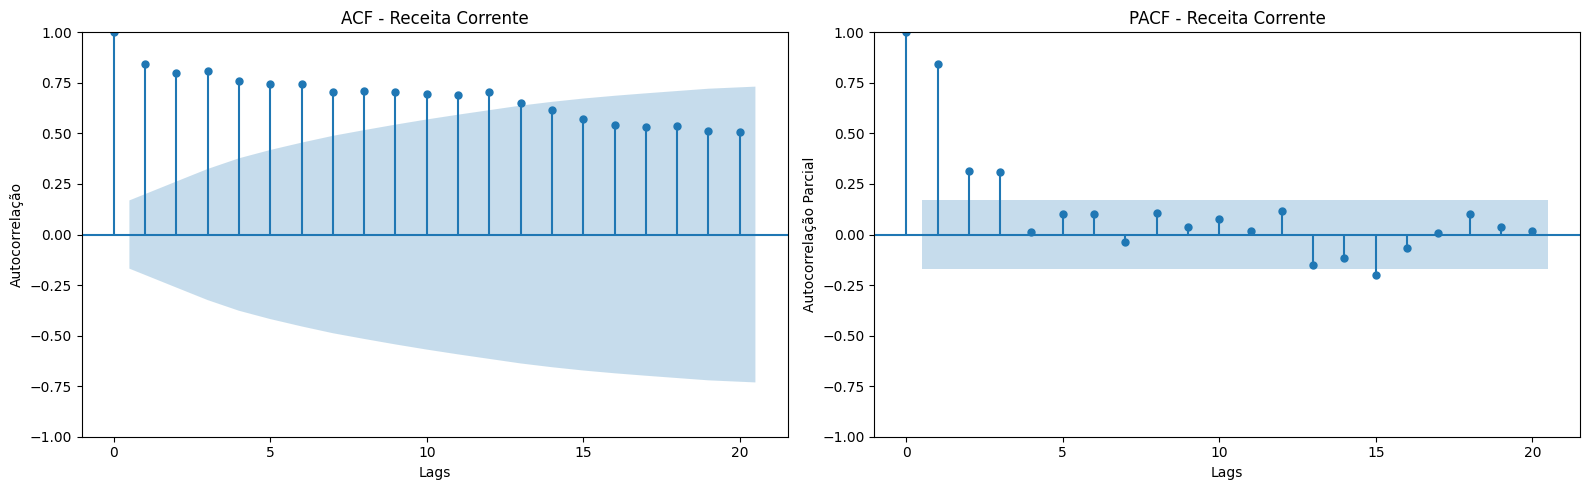

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(RC['9. Receita Corrente'], ax=axes[0], lags=20)
axes[0].set_title('ACF - Receita Corrente')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelação')  
plot_pacf(RC['9. Receita Corrente'], ax=axes[1], lags=20)
axes[1].set_title('PACF - Receita Corrente')   
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Autocorrelação Parcial')
plt.tight_layout()
plt.show()    


Gráficos ACF e PACF: Deduções

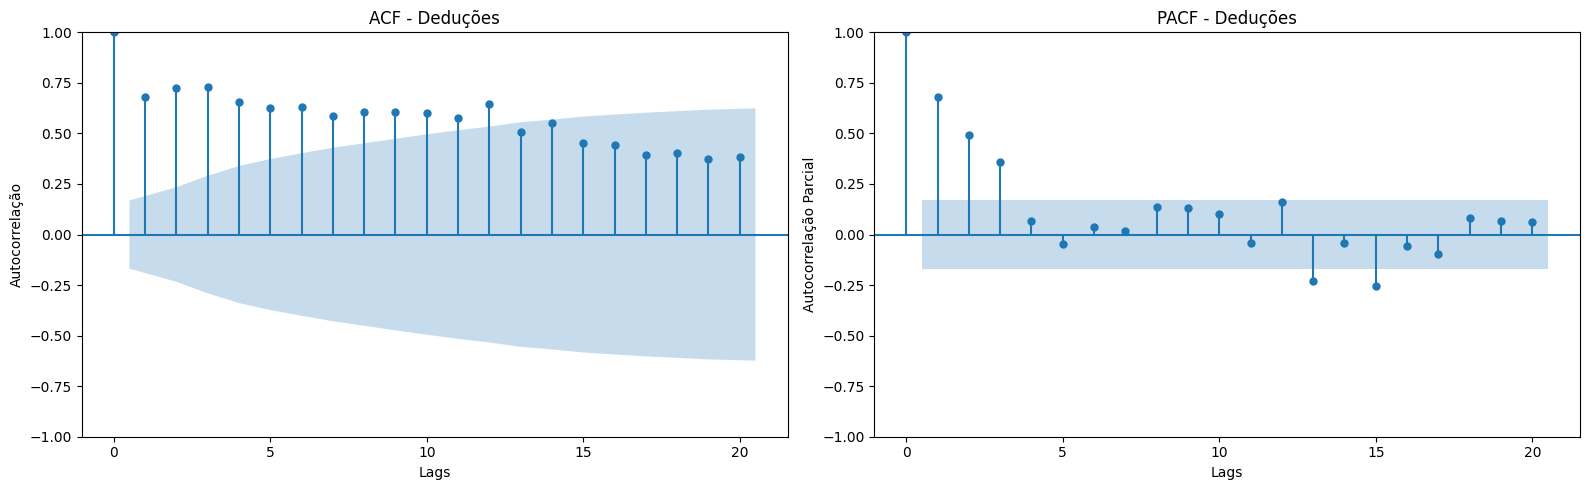

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(DE['10. Deduções'], ax=axes[0], lags=20)
axes[0].set_title('ACF - Deduções')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelação')  
plot_pacf(DE['10. Deduções'], ax=axes[1], lags=20)
axes[1].set_title('PACF - Deduções')   
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Autocorrelação Parcial')
plt.tight_layout()
plt.show()    
